In [9]:
import tensorflow as tf

#defining variables 
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

CLASS_NAMES = ["Lilly","Lotus","Orchid","Sunflower","Tulip"]

In [10]:
def read_and_decode(filename, resize_dims):
    # 1. read the files
    img_bytes = tf.io.read_file(filename)

    #2 . Decode image data
    img = tf.image.decode_jpeg(img_bytes, channels = IMG_CHANNELS)

    #3. convert pixel valuse to floats in [0,1]
    img = tf.image.convert_image_dtype(img, tf.float32)

    #4. resiize the image to match the desire diimensions
    img = tf.image.resize(img, resize_dims)
    return img

In [11]:
def parse_csvline(csv_line):
    #record_defaults specify the data types for each colum
    record_default = ["", ""]
    filename, label_string = tf.io.decode_csv(csv_line, record_default)

    #load the image
    img = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])

    #convert  label string to integer based on thee CLASS_NAMES index
    label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))
    return img, label

In [12]:
train_dataset = (
    tf.data.TextLineDataset("data/train_set.csv")
    .skip(1)
    .map(parse_csvline)
    .batch(16)
)

eval_dataset = (
    tf.data.TextLineDataset("data/eval_set.csv")
    .skip(1)
    .map(parse_csvline)
    .batch(16)
)

In [18]:
for image_batch, label_batch in train_dataset.take(3):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Labels:", label_batch.numpy())

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Labels: [1 2 2 1 0 0 0 2 2 1 2 0 0 0 3 3]
Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Labels: [1 3 1 1 0 3 1 0 4 0 4 0 4 0 1 0]
Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Labels: [4 4 1 2 3 4 4 2 3 4 0 0 0 3 3 4]


In [14]:
import csv
import pandas as pd

In [15]:
df = pd.read_csv('data/train_set.csv')    

In [16]:
df.head()

,image_path,label
0,data/flower_images\Lotus\81d74b1184.jpg,Lotus
1,data/flower_images\Orchid\9a3230fab6.jpg,Orchid
2,data/flower_images\Orchid\a792a1c723.jpg,Orchid
3,data/flower_images\Lotus\10012f282d.jpg,Lotus
4,data/flower_images\Lilly\b315379e24.jpg,Lilly


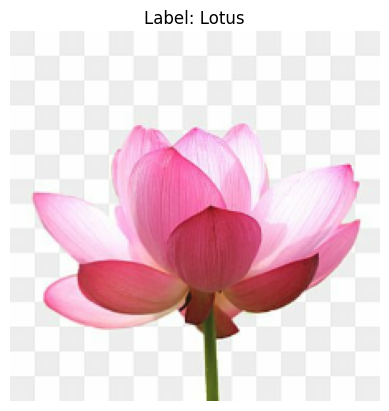

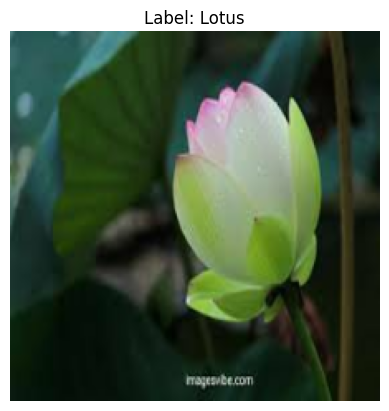

In [21]:
import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(2):
    #take the first image from the batch
    first_image = image_batch[0]
    first_label = label_batch[0]

    #convert the tensor to a numpy array
    plt.imshow(first_image.numpy())
    plt.title(f"Label: {CLASS_NAMES[first_label]}")
    plt.axis("off")
    plt.show()
    

In [22]:
for image_batch, label_batch in train_set.take(1):
    fig, axes = plt.subplots(4, 4, figsize=[10,10])

    for i in range(16):
        ax = axes[i // 4, i % 4]
        ax.imshow(image_batch[i].numpy())
        ax.set_title(f"label: {CLASS_NAMES[label

IndentationError: expected an indented block after 'for' statement on line 1 (2536615394.py, line 1)